# Dynamic Data Augmentation

Dynamic data augmentation applies transformations to images during training rather than beforehand. Unlike static augmentation—such as techniques used for dataset balancing—where modified images are preprocessed and stored, dynamic augmentation generates new variations in each training iteration. This approach improves model generalization by exposing it to a wider range of variations, reducing overfitting, and enhancing robustness.

We will explore two levels of data augmentation in a subset of the GTSRB:

- **Without increasing the dataset size**: Each image undergoes random transformations in every epoch, ensuring the model never sees the exact same image twice.

- **Expanding the dataset**: Multiple transformations are applied to each image, effectively increasing the dataset size by including different augmented versions.

In this notebook, we will apply some of the transformations explored in the previous notebook.

In [21]:
import torch
import torchvision
from torchvision.transforms import v2

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

## Auxiliary functions from previous classes

In [ ]:
def show_bad_preds(model, dataset, classes):
    k = 0
    iters = 0

    preds = []
    ground_truth = []
    imgs = torch.Tensor(52, 3, 32,32)

    iterator = iter(dataset)

    max_iters = test_set.__len__() / BATCH_SIZE
    while k < 52 and iters < max_iters:

        images, targets = next(iterator)
        #print(images[0].shape)
        logits = model(images.to(device))
        
        #print(predictions[0])
        predictions = torch.nn.functional.softmax(logits, dim=1).cpu().detach().numpy()
        for i in range(len(predictions)):

            if np.argmax(predictions[i]) != targets[i] and k < 52:

                preds.append(predictions[i])
                ground_truth.append(targets[i])
                imgs[k, :, :, :] = images[i]
                k += 1

        iters += 1

    vcpi_util.plot_predictions(imgs, preds, ground_truth, classes, 13, 4)




def train_III(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix = 'model'):

    history = {}
    history['accuracy'] = []
    history['val_acc'] = []
    history['val_loss'] = []
    history['loss'] = []
    best_val_loss = np.inf

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        start_time = time.time() 
        correct = 0
        running_loss = 0.0
        for i, (inputs, targets) in enumerate(train_loader, 0):
            
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            loss = loss_fn(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            correct += (predicted == targets).sum()

        model.eval()
        with torch.no_grad():
            v_correct = 0
            val_loss = 0.0
            for i,t in val_loader:
                i = i.to(device)
                t = t.to(device)
                o = model(i)
                _,p = torch.max(o,1)
                
                val_loss += loss_fn(o, t).item() * t.size(0)

                v_correct += (p == t).sum()

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = 100 * correct / len(train_loader.dataset)
        v_accuracy = 100 * v_correct / len(val_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        stop_time = time.time()
        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; Accuracy: {accuracy:0.4f}; Val Loss: {val_loss:0.6f}; Val Acc: {v_accuracy:0.4f}; Elapsed time: {(stop_time - start_time):0.4f}')
        history['accuracy'].append(accuracy.cpu().numpy())
        history['val_acc'].append(v_accuracy.cpu().numpy())
        history['val_loss'].append(val_loss)
        history['loss'].append(epoch)
 
        ###### Saving ######
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model':model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
                },
                f'{save_prefix}.pt')

        if early_stopper(val_loss):
            print('Early stopping!')
            break
        
    print('Finished Training')

    return(history)

def evaluate(model, data_loader):

    # sets the model in evaluation mode.
    # although our model does not have layers which behave differently during training and evaluation
    # this is a good practice as the models architecture may change in the future
    model.eval()

    correct = 0
    with torch.no_grad():
        for i, (images, targets) in enumerate(data_loader):
            
            # forward pass, compute the output of the model for the current batch
            outputs = model(images.to(device))

            # "max" returns a namedtuple (values, indices) where values is the maximum 
            # value of each row of the input tensor in the given dimension dim; 
            # indices is the index location of each maximum value found (argmax).
            # the argmax effectively provides the predicted class number        
            _, preds = torch.max(outputs, dim=1)

            correct += (preds.cpu() == targets).sum()

    return (correct / len(data_loader.dataset)).item()



class Conv_II(torch.nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        
        # Block 1
        self.conv1 = torch.nn.Conv2d(3, 16, 3)
        self.bn1 = torch.nn.BatchNorm2d(16)
        self.relu1 = torch.nn.ReLU()
        
        self.conv2 = torch.nn.Conv2d(16, 32, 3)
        self.bn2 = torch.nn.BatchNorm2d(32)
        self.relu2 = torch.nn.ReLU()
        
        self.maxpool1 = torch.nn.MaxPool2d(2)

        # Block 2
        self.conv3 = torch.nn.Conv2d(32, 48, 3)
        self.bn3 = torch.nn.BatchNorm2d(48)
        self.relu3 = torch.nn.ReLU()
        
        self.conv4 = torch.nn.Conv2d(48, 48, 3)
        self.bn4 = torch.nn.BatchNorm2d(48)
        self.relu4 = torch.nn.ReLU()
        
        self.maxpool2 = torch.nn.MaxPool2d(2)
    
        # Dropout (p=0.5 drops 50% of the neurons randomly during training)
        self.dropout = torch.nn.Dropout(p=0.5)

        # Fully Connected (GAP outputs 48 channels as scalars -> 48 inputs)
        self.fc1 = torch.nn.Linear(48, num_classes)
        

    def forward(self, x):    
        
        # input = (bs, 3, 32, 32)
        x = self.conv1(x)       # -> (bs, 16, 30, 30)
        x = self.bn1(x)
        x = self.relu1(x)
        
        x = self.conv2(x)       # -> (bs, 32, 28, 28)
        x = self.bn2(x)
        x = self.relu2(x)
        
        x = self.maxpool1(x)    # -> (bs, 32, 14, 14)
        
        x = self.conv3(x)       # -> (bs, 48, 12, 12)
        x = self.bn3(x)
        x = self.relu3(x)
        
        x = self.conv4(x)       # -> (bs, 48, 10, 10)
        x = self.bn4(x)
        x = self.relu4(x)
        
        x = self.maxpool2(x)    # -> (bs, 48, 5, 5)
        
        # Apply GAP using torch.mean
        x = torch.mean(x, dim=[2, 3])   # -> (bs, 48)
        
        # Apply Dropout
        x = self.dropout(x)
        
        # Classifier
        x = self.fc1(x)         # -> (bs, 10)

        return x

class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta
        self.counter = 0

        self.min_delta
        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False
    

## Settings

In [26]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

BASE_PATH = 'd:/vcpi/gtsrb'

PATH_TRAINING_SET = f'{BASE_PATH}/train_balanced_2000'
PATH_TEST_SET = f'{BASE_PATH}/test_A'
PATH_VAL_SET = f'{BASE_PATH}/val'

BATCH_SIZE = 32

EPOCHS = 50

RUNS = 5

cuda:0


In [ ]:
transform = v2.Compose(
    [v2.Resize((32,32)), 
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)]) 

# No shuffle is required for the test set, also the batch size can be completely different
test_set = torchvision.datasets.ImageFolder(root=PATH_TEST_SET, transform = transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE)

val_set = torchvision.datasets.ImageFolder(root=PATH_VAL_SET, transform = transform)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)

train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

## Previous accuracy performance

show accuracies for models trained with data augmentation from balancing the dataset

In [27]:
res = 0
model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'gtsrb_balanced_{i}.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)    
    res += eval

res /= RUNS    
print(res)

26 0.979376494884491 0.989534854888916
22 0.9827337861061096 0.9860464930534363
29 0.9880095720291138 0.9918604493141174
24 0.9839328527450562 0.9891473054885864
27 0.991127073764801 0.9899224638938904
0.9850359559059143


## Data augmentation
 
### Setting up a transform for dynamic data augmentation

In [28]:
transform_aug = v2.Compose(
    [v2.Resize((32,32)), 
     v2.RandomAffine(degrees=10, translate = [0.05, 0.05], interpolation =v2.InterpolationMode.BILINEAR), 
     v2.ColorJitter(brightness = 0.5, contrast = 0.5,hue = 0.1),
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)]) 

train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = transform_aug)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

### Training

In [31]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_II = Conv_II(len(train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'aug_I_{i}')

Epoch: 000; Loss: 1.727806; Accuracy: 32.7688; Val Loss: 2.085632; Val Acc: 18.1783; Elapsed time: 17.7648
Epoch: 001; Loss: 1.129103; Accuracy: 60.9000; Val Loss: 1.014982; Val Acc: 66.8992; Elapsed time: 16.7328
Epoch: 002; Loss: 0.634351; Accuracy: 80.2750; Val Loss: 0.601341; Val Acc: 80.0000; Elapsed time: 16.3807
Epoch: 003; Loss: 0.412290; Accuracy: 87.5688; Val Loss: 0.710999; Val Acc: 76.5116; Elapsed time: 16.4725
Epoch: 004; Loss: 0.296302; Accuracy: 91.2250; Val Loss: 0.247594; Val Acc: 91.5504; Elapsed time: 16.5588
Epoch: 005; Loss: 0.234477; Accuracy: 93.1375; Val Loss: 0.093122; Val Acc: 97.7132; Elapsed time: 16.9273
Epoch: 006; Loss: 0.192688; Accuracy: 94.3688; Val Loss: 0.105125; Val Acc: 97.5194; Elapsed time: 16.7673
Epoch: 007; Loss: 0.151610; Accuracy: 95.5938; Val Loss: 0.081667; Val Acc: 98.1783; Elapsed time: 16.5237
Epoch: 008; Loss: 0.137225; Accuracy: 96.0313; Val Loss: 0.109019; Val Acc: 97.2868; Elapsed time: 17.1379
Epoch: 009; Loss: 0.115069; Accuracy:

### Evaluating

In [32]:
res = 0
model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'aug_I_{i}.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)
    res += eval

res /= RUNS    
print(res)

33 0.9930455684661865 0.9941860437393188
29 0.9942445755004883 0.9941860437393188
21 0.9923261404037476 0.9957364201545715
28 0.9947242140769958 0.9972867965698242
39 0.992565929889679 0.9957364201545715
0.9933812856674195


Show misclassifications for the last model

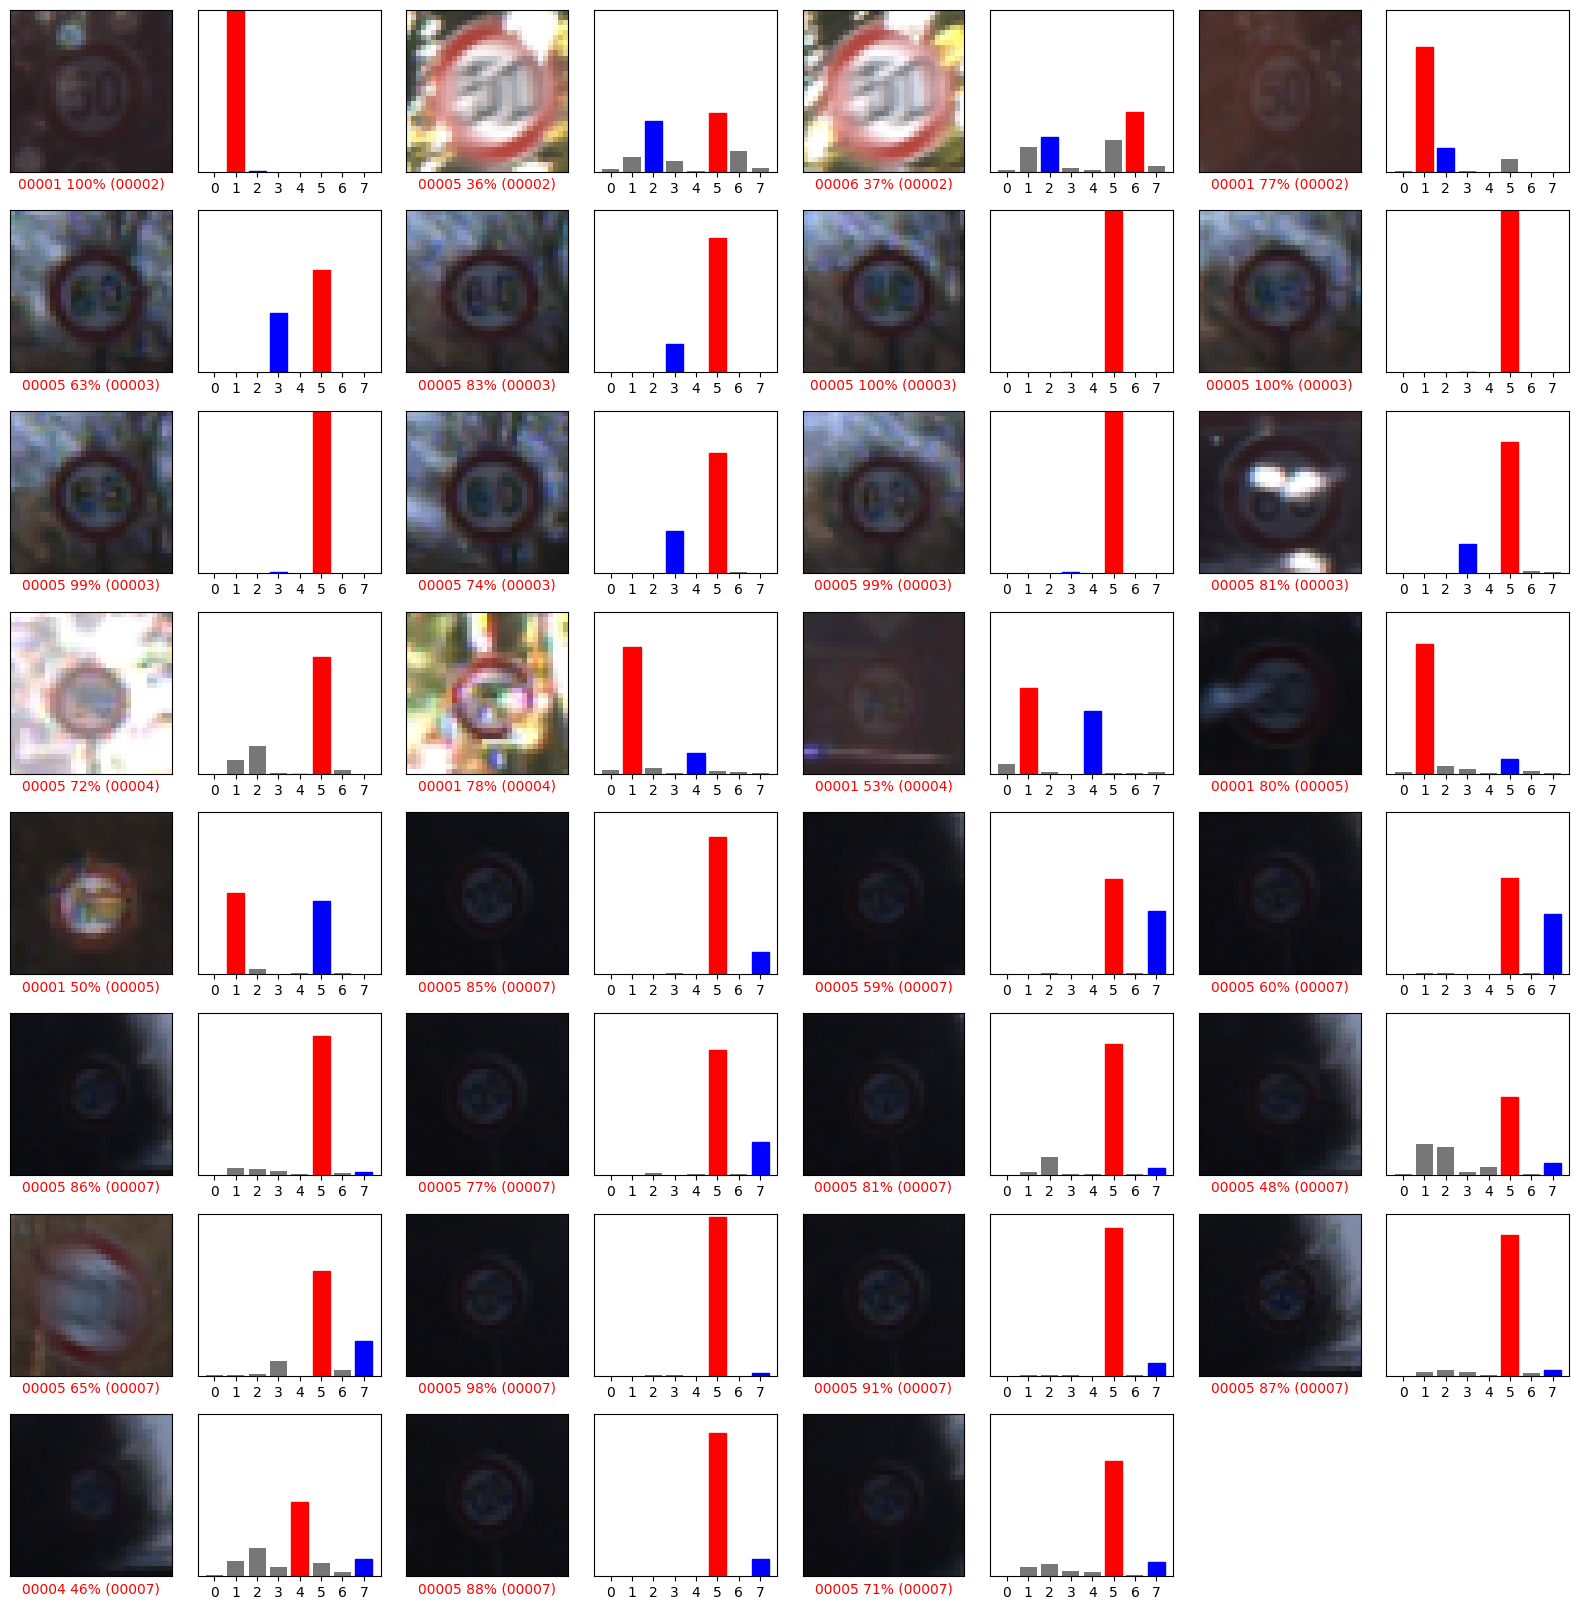

In [33]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   

## Massive Data Augmentation

Here, we will significantly expand the dataset by applying multiple transformations in combination.

### Setting the transform

In [34]:
transform_A = v2.Compose(
    [v2.Resize((32,32)), 
     v2.RandomAffine(degrees=10, translate = [0.05, 0.05],interpolation =v2.InterpolationMode.BILINEAR), 
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)]) 

transform_B = v2.Compose(
    [v2.Resize((32,32)), 
     v2.RandomAffine(degrees=10, translate = [0.05, 0.05],interpolation =v2.InterpolationMode.BILINEAR), 
     v2.ColorJitter(brightness = 0.5), 
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)]) 

transform_C = v2.Compose(
     [v2.Resize((32,32)), 
     v2.RandomAffine(degrees=10, translate = [0.05, 0.05],interpolation =v2.InterpolationMode.BILINEAR), 
     v2.ColorJitter(contrast = 0.5), 
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)])

transform_D = v2.Compose(
     [v2.Resize((32,32)), 
     v2.RandomAffine(degrees=10, translate = [0.05, 0.05],interpolation =v2.InterpolationMode.BILINEAR), 
     v2.ColorJitter(hue = 0.1), 
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)])    



train_loader = torch.utils.data.DataLoader(
    torch.utils.data.ConcatDataset([   
        torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform=transform_A),
        torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform=transform_B),
        torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform=transform_C),
        torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform=transform_D),
    ]),  batch_size = BATCH_SIZE, shuffle = True)

#train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = transform_A)
#train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

### Training

In [35]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_III = Conv_II(len(train_set.classes))
    model_Conv_III.to(device)

    early_stop = Early_Stopping(9)
    optimizer_III = torch.optim.Adam(model_Conv_III.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_III, mode='min', factor = 0.1, patience=3)

    history_III = train_III(model_Conv_III, train_loader , val_loader, EPOCHS, loss_fn, optimizer_III, scheduler, early_stop, f'aug_II_{i}')

Epoch: 000; Loss: 0.947945; Accuracy: 66.0422; Val Loss: 0.298403; Val Acc: 90.4264; Elapsed time: 55.1537
Epoch: 001; Loss: 0.166263; Accuracy: 95.3609; Val Loss: 0.077124; Val Acc: 98.0233; Elapsed time: 55.5140
Epoch: 002; Loss: 0.079295; Accuracy: 97.8813; Val Loss: 0.079315; Val Acc: 97.5581; Elapsed time: 53.9823
Epoch: 003; Loss: 0.053210; Accuracy: 98.5344; Val Loss: 0.068244; Val Acc: 97.9845; Elapsed time: 53.7569
Epoch: 004; Loss: 0.038042; Accuracy: 98.9703; Val Loss: 0.056145; Val Acc: 98.3721; Elapsed time: 55.2841
Epoch: 005; Loss: 0.033586; Accuracy: 99.0703; Val Loss: 0.056312; Val Acc: 98.3721; Elapsed time: 55.0601
Epoch: 006; Loss: 0.031072; Accuracy: 99.1359; Val Loss: 0.044228; Val Acc: 98.5271; Elapsed time: 55.0557
Epoch: 007; Loss: 0.026337; Accuracy: 99.2938; Val Loss: 0.043726; Val Acc: 98.4496; Elapsed time: 55.3669
Epoch: 008; Loss: 0.023425; Accuracy: 99.3203; Val Loss: 0.039291; Val Acc: 98.6822; Elapsed time: 55.8848
Epoch: 009; Loss: 0.022330; Accuracy:

### Evaluating

In [37]:
res = 0
model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'aug_II_{i}.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)    
    res += eval

res /= RUNS    
print(res)

23 0.9935252070426941 0.9965116381645203
25 0.9959232807159424 0.9988372325897217
13 0.9928057789802551 0.9968992471694946
41 0.9954436421394348 0.9961240291595459
15 0.9930455684661865 0.998062014579773
0.9941486954689026


Show misclassifications for the last model

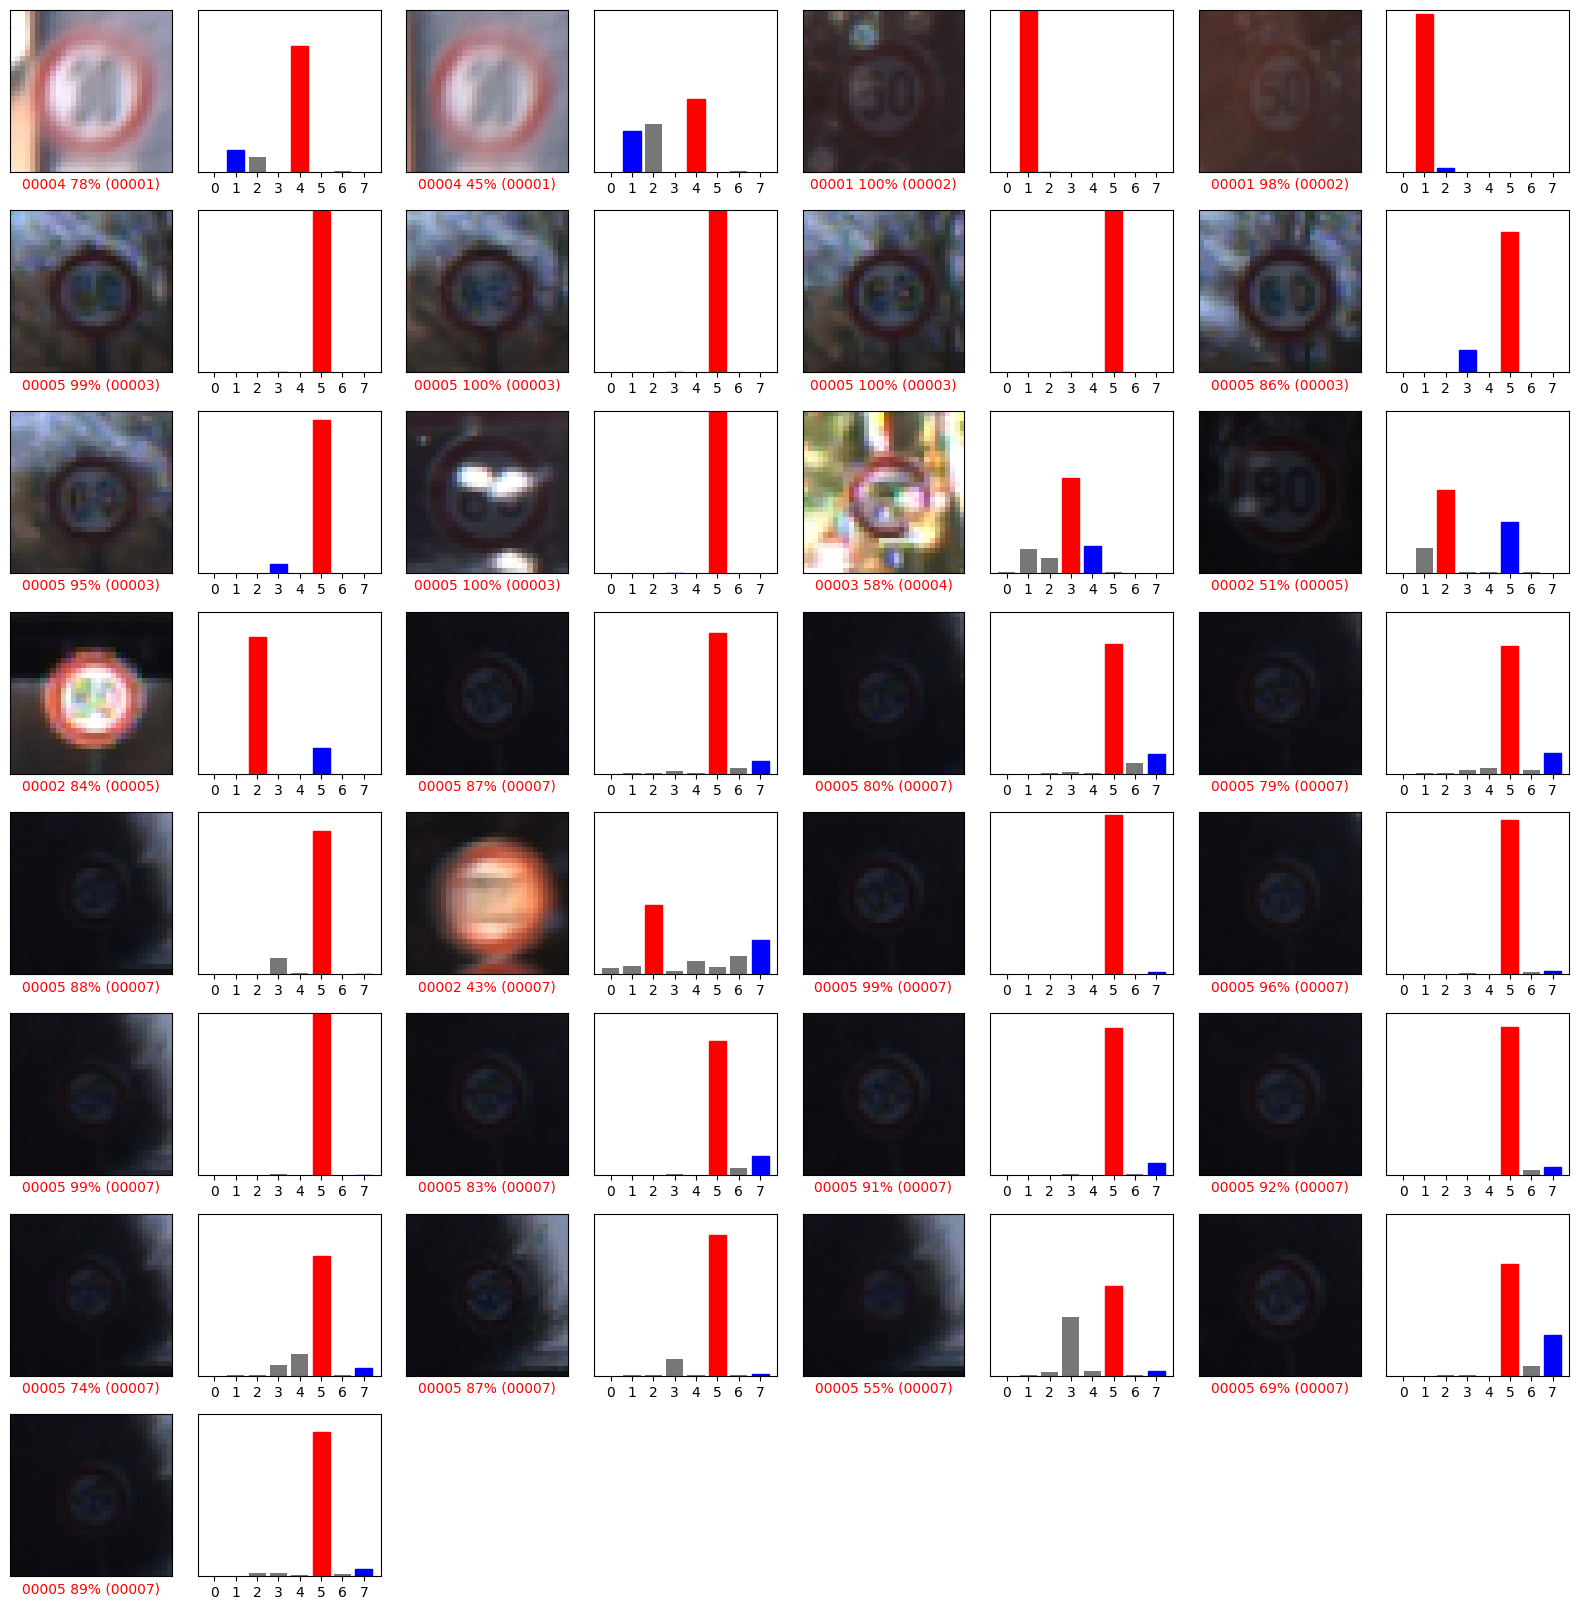

In [38]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   

# Testing on traffic signs from other datasets

## rMASTIF (Croatian dataset)

The Croatian dataset has traffic signs with speed limits, but only for 30, 50, 60,  and 70 km/h

The dataset can be download [here](https://www.zemris.fer.hr/~kalfa/Datasets/rMASTIF/)

In [39]:
test_set = torchvision.datasets.ImageFolder(root='d:/vcpi/croatian_test_common', transform = transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE)


In [40]:
res = 0
model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'aug_I_{i}.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)
    res += eval

res /= RUNS    
print(res)

33 0.9934210777282715 0.9941860437393188
29 0.9949690699577332 0.9941860437393188
21 0.9922600388526917 0.9957364201545715
28 0.9934210777282715 0.9972867965698242
39 0.9926470518112183 0.9957364201545715
0.9933436632156372


In [41]:
res = 0
model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'aug_II_{i}.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)    
    res += eval

res /= RUNS    
print(res)

23 0.9938080310821533 0.9965116381645203
25 0.9949690699577332 0.9988372325897217
13 0.9930340647697449 0.9968992471694946
41 0.9957430362701416 0.9961240291595459
15 0.9945820569992065 0.998062014579773
0.9944272518157959


# BTSC (Belgian Traffic Sign Classification)

The BTSC has traffic signs with speed limits, but only for 30, 50, and 70 km/h

BTSC can be downloaded [here](https://btsd.ethz.ch/shareddata/)

In [47]:
test_set = torchvision.datasets.ImageFolder(root='d:/vcpi/belgium_test_common', transform = transform, target_transform = None)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE)

In [48]:
res = 0
model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'aug_I_{i}.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)
    res += eval

res /= RUNS    
print(res)

33 0.978672981262207 0.9941860437393188
29 0.9857819676399231 0.9941860437393188
21 0.9810426831245422 0.9957364201545715
28 0.971563994884491 0.9972867965698242
39 0.9739336371421814 0.9957364201545715
0.978199052810669


In [49]:
res = 0
model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

for i in range(RUNS):

    reload = torch.load(f'aug_II_{i}.pt')
    model_Conv.load_state_dict(reload['model'])
    eval = evaluate(model_Conv, test_loader)
    eval_val = evaluate(model_Conv, val_loader)
    print(reload['epoch'], eval, eval_val)    
    res += eval

res /= RUNS    
print(res)

23 0.9857819676399231 0.9965116381645203
25 0.9857819676399231 0.9988372325897217
13 0.9834123253822327 0.9968992471694946
41 0.9834123253822327 0.9961240291595459
15 0.9834123253822327 0.998062014579773
0.9843601822853089


Note: the stop signs that may appear in the images below are due to the fact that this version of pytorch does not accept empty folders in the dataset.

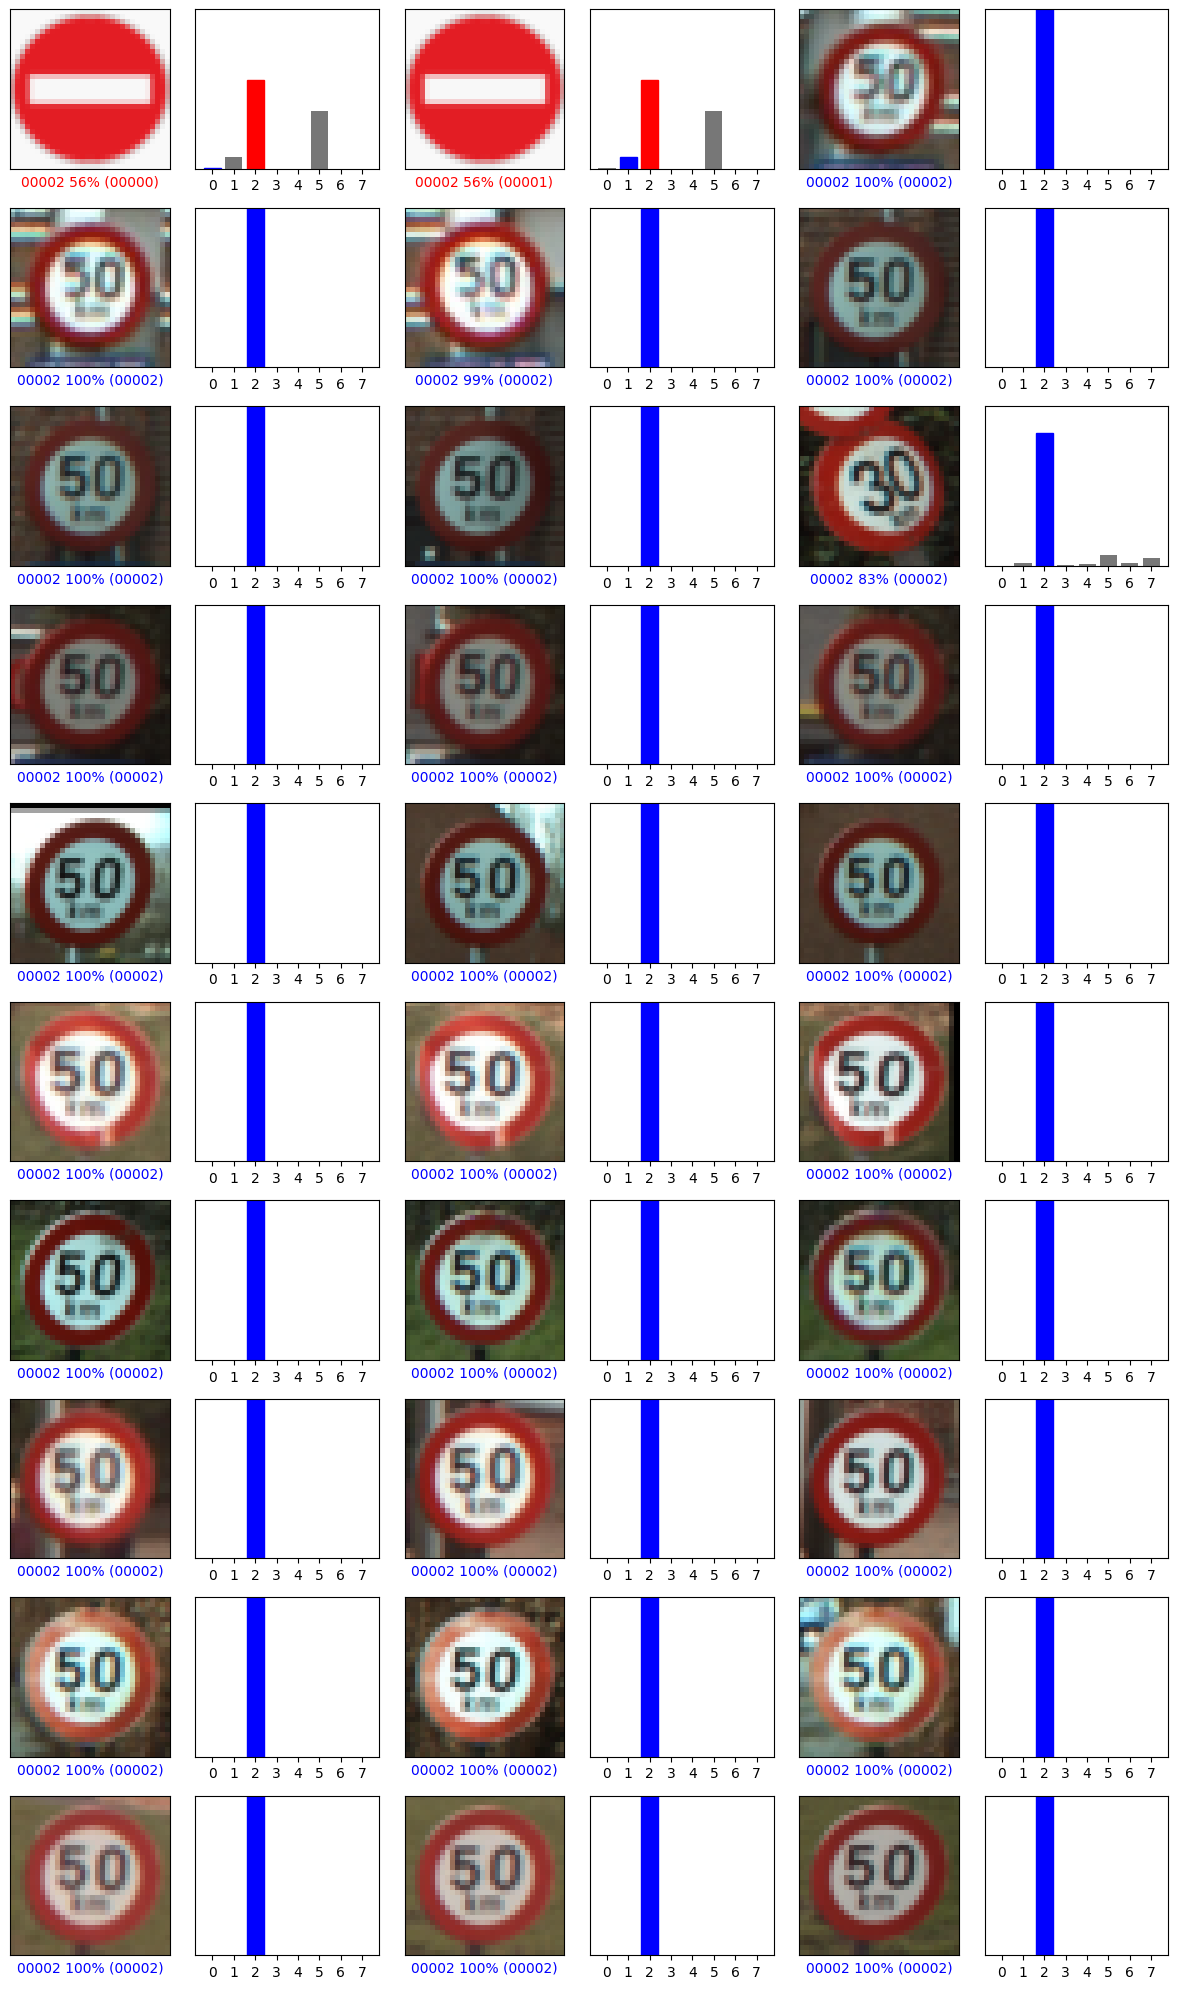

In [50]:
images, targets = next(iter(test_loader))
model_Conv.eval()
logits = model_Conv(images.to(device))

predictions = torch.nn.functional.softmax(logits, dim=1).cpu().detach().numpy()
vcpi_util.plot_predictions(images, predictions, targets, train_set.classes, 10, 3)

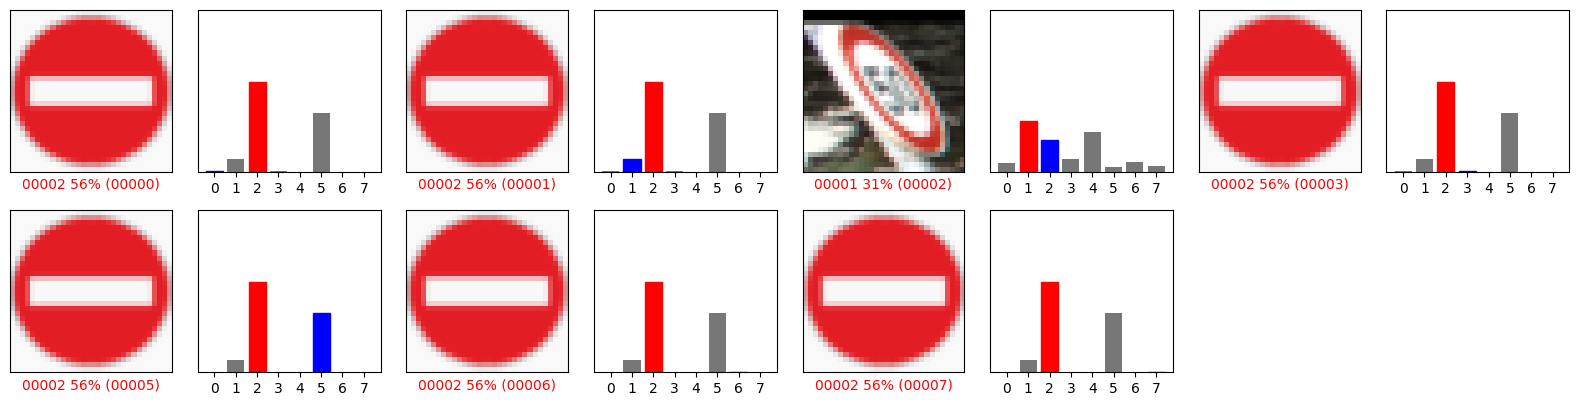

In [51]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   